# PHASE 5: Model Selection, Training & Validation
**Traceability**
- Issue ID: #5 Model Selection, Training & Validation

**External References**:
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (XGBoost & CV Strategy)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Classical Baselines)

## 1. Objectives
- **Reasoning**: We need a validation strategy that mimics deployment. Random splitting causes data leakage because samples from the same engine are highly correlated. We use **GroupKFold**.
- **Action**: Tune hyperparameters for the best model.
- **Evaluation**: Analyze residuals to ensure no systematic bias.

## 2. Model Strategy
- Linear Regression
- XGBoost
- Random Forest
- Support Vector Regression (SVR)
- Neural Network (ANN)
- LightBGM
- **Evaluation**: Compare model performance using metrics like RMSE, MAE, and R².

##  Common Blocks 
Common Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import pickle

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

Load Data + Common Setup

In [2]:
# 1. Setup constants
# Files are in the current working directory
PROCESSED_DIR = Path("../data/experiments/DS-C")
target_col = "RUL_clipped"
group_col = "unit_number"
MAX_RUL = 125

# 2. Load the three datasets
train_df = pd.read_csv(PROCESSED_DIR/"train.csv")
test_df = pd.read_csv(PROCESSED_DIR/"test.csv")

# Apply Piecewise RUL (Clipping)
# (Ensuring RUL is capped at MAX_RUL as per your logic)
train_df[target_col] = train_df[target_col].clip(upper=MAX_RUL)
test_df[target_col] = test_df[target_col].clip(upper=MAX_RUL)

# Preprocessing: Clip RUL
for df in [train_df, test_df]:
    df[target_col] = df[target_col].clip(upper=MAX_RUL)

# Identify features (Exclude target and unit_number)
exclude_cols = [target_col, group_col]
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

# Clean way to separate features and targets
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Check for unit_number to use GroupKFold
if group_col in train_df.columns:
    groups = train_df[group_col]
    cv_strategy = GroupKFold(n_splits=5)
    print(f"Dataset contains '{group_col}'. Using GroupKFold for validation.")
else:
    groups = None
    cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
    print(f"'{group_col}' NOT found. Using standard KFold validation.")

print(f"Features used: {feature_cols}")
print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Dataset contains 'unit_number'. Using GroupKFold for validation.
Features used: ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12', 'PC_13', 'PC_14', 'PC_15', 'PC_16', 'PC_17', 'PC_18', 'PC_19', 'PC_20', 'PC_21', 'PC_22', 'PC_23', 'PC_24', 'PC_25', 'PC_26', 'PC_27', 'PC_28', 'PC_29', 'PC_30', 'PC_31', 'PC_32', 'PC_33']
Training shape: (20631, 33)
Test shape: (13096, 33)


A1) NASA Scoring Function

In [3]:
def nasa_scoring_function(y_true, y_pred):
    """
    Official NASA asymmetric scoring. 
    Penalizes over-estimation (late maintenance) much harder than under-estimation.
    Lower is better. Penalizes late predictions more than early ones.
    """
    d = y_pred - y_true
    # Formula: d < 0 (early) -> exp(-d/13)-1 | d > 0 (late) -> exp(d/10)-1
    score = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(score)

A2) Regression Report Function

In [4]:
def regression_report(y_train, pred_train, y_test, pred_test, title="Model Evaluation"):
    
    # Helper to calculate metrics
    def get_metrics(y_true, y_pred):
        rmse = root_mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        # Calculate NASA score
        nasa = nasa_scoring_function(y_true, y_pred)
        
        # Accuracy within 10 cycles
        acc = np.mean(np.abs(y_true - y_pred) <= 10) * 100
        return [rmse, mae, r2, nasa, acc]

    train_stats = get_metrics(y_train, pred_train)
    test_stats = get_metrics(y_test, pred_test)

    print(f"\n{'='*25} {title} {'='*25}")
    print(f"{'Metric':<18} | {'Train':<12} | {'Test':<12}")
    print(f"{'-'*68}")
    
    metrics_names = ["RMSE", "MAE", "R2 Score", "NASA Score", "Accuracy (±10)"]
    
    for name, tr, te in zip(metrics_names, train_stats,  test_stats):
        print(f"{name:<18} | {tr:<12.4f} | {te:<12.4f}")

    # Overfitting Check: If Train RMSE is significantly lower than Test
    if train_stats[0] < (test_stats[0] * 0.7):
        diff = ((test_stats[0] - train_stats[0]) / test_stats[0]) * 100
        print(f"\n⚠️  WARNING: Potential Overfitting! Train RMSE is {diff:.1f}% lower than Test.")

    return {
        "train": {"rmse": train_stats[0], "r2": train_stats[2], "nasa": train_stats[3]},
        "test":  {"rmse": test_stats[0], "r2": test_stats[2], "nasa": test_stats[3]}
    }

A3) Alignment Check Function

In [5]:
def check_alignment(datasets, title="Error Alignment Comparison"):
    """
    datasets: List of tuples [(y_true, y_pred, 'Label'), ...]
    Example: check_alignment([(y_valid, pred_valid, 'Validation'), (y_test, pred_test, 'Test')])
    """
    plt.figure(figsize=(12, 6))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
    
    for i, (y_true, y_pred, label) in enumerate(datasets):
        errors = np.abs(y_true - y_pred)
        plt.scatter(y_true, errors, alpha=0.4, label=f'{label} Errors', color=colors[i % 3])
    
    plt.axhline(10, color='r', linestyle='--', label='Accuracy Threshold (±10)')
    
    # NASA RUL models usually get noisier at high RUL (early life)
    # and more accurate at low RUL (near failure).
    plt.title(title)
    plt.xlabel("Actual RUL (Cycles left)")
    plt.ylabel("Absolute Error")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

A4) Model Evaluation

In [6]:
def plot_comparison(y_true, y_pred, title="Actual vs Predicted RUL"):
    """
    Plots a comparison between actual and predicted RUL.
    Automatically sorts by True RUL to show performance across engine life stages.
    """
    # 1. Ensure data is flat and converted to numpy
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # 2. Sort both arrays based on True RUL values
    # This makes the plot readable even with thousands of data points
    sort_idx = np.argsort(y_true)
    y_true_sorted = y_true[sort_idx]
    y_pred_sorted = y_pred[sort_idx]
    
    plt.figure(figsize=(12, 6))
    
    # 3. Plotting
    # We use a line for the ground truth and dots for predictions
    plt.plot(y_true_sorted, label='True RUL (Ground Truth)', color='royalblue', linewidth=3, alpha=0.8)
    plt.scatter(range(len(y_pred_sorted)), y_pred_sorted, label='Predicted RUL', 
                color='red', s=10, alpha=0.4)
    
    plt.xlabel("Observations (Sorted by RUL)", fontsize=12)
    plt.ylabel("Remaining Useful Life (Cycles)", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

A5)Model Comparison (CV)

In [7]:
def display_model_comparison(results_cv):
    # Convert dictionary to DataFrame
    df_results = pd.DataFrame(results_cv).T
    
    # Sort by RMSE (Primary metric for RUL)
    df_results = df_results.sort_values(by='CV_RMSE', ascending=True)
    
    # Style the table for better readability
    print("### Model Performance Comparison (Cross-Validation) ###")
    display(df_results.style.highlight_min(subset=['CV_RMSE', 'CV_MAE'], color='green')
                      .highlight_max(subset=['CV_R2'], color='green'))
    
    return df_results

def plot_model_comparison(df_results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['CV_RMSE', 'CV_MAE', 'CV_R2']
    colors = ['skyblue', 'salmon', 'lightgreen']
    
    for i, metric in enumerate(metrics):
        # Sort values for the specific plot
        temp_df = df_results[metric].sort_values(ascending=(metric != 'CV_R2'))
        temp_df.plot(kind='barh', ax=axes[i], color=colors[i])
        axes[i].set_title(f'Model Comparison: {metric}')
        axes[i].set_xlabel('Score')
        
    plt.tight_layout()
    plt.show()

A6) Model Comparison (Full Performance)

In [8]:
def get_full_performance_report(trained_models, train_df,  test_df, features, target):
    rows = []
    
    for name, model in trained_models.items():
        # Dictionary to store metrics for this model
        model_results = {'Model': name}
        
        # Datasets to evaluate
        datasets = [('Train', train_df),  ('Test', test_df)]
        
        for split_name, df in datasets:
            X = df[features]
            y = df[target]
            preds = model.predict(X)
            
            # Calculate Metrics
            model_results[f'{split_name}_RMSE'] = root_mean_squared_error(y, preds)
            model_results[f'{split_name}_MAE'] = mean_absolute_error(y, preds)
            model_results[f'{split_name}_R2'] = r2_score(y, preds)
            
        rows.append(model_results)
    
    # Create DataFrame and sort by Test RMSE (The ultimate goal)
    report_df = pd.DataFrame(rows).set_index('Model').sort_values('Test_RMSE')
    return report_df

def plot_split_comparison(report_df):
    # Select only RMSE columns for a cleaner chart
    rmse_cols = ['Train_RMSE', 'Test_RMSE']
    report_df[rmse_cols].plot(kind='bar', figsize=(12, 6), colormap='viridis')
    
    plt.title('RMSE Comparison: Train vs Test')
    plt.ylabel('RMSE (Lower is Better)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

## MODEL -  Traditional

### Import the necessary libraries

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb

### Model setup

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

# Optimized Models for NASA C-MAPSS (Anti-Overfitting Focus)
models = {
    # 1. Linear Regression (Using Ridge for better generalization via L2)
    "Linear Regression": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    
    # 2. Decision Tree (Restricted to prevent deep vertical overfitting)
    "Decision Tree": make_pipeline(StandardScaler(), DecisionTreeRegressor(
        max_depth=6,              # Reduced from 8 to prevent complex local patterns
        min_samples_leaf=40,      # Increased to ensure more statistical significance per leaf
        min_samples_split=100,    # High split threshold to keep trees simple
        random_state=42
    )),
    
    # 3. Random Forest (Focus on high-bias ensemble)
    "Random Forest": make_pipeline(StandardScaler(), RandomForestRegressor(
        n_estimators=500,         # 1000 is often overkill; 500 is stable enough
        max_depth=8,              # Controlled depth
        max_features=0.5,         # Feature sampling (50%) forces diversity
        min_samples_leaf=30,      
        n_jobs=-1, 
        random_state=42
    )),
    
    # 4. XGBoost (Aggressive Regularization for Time-Series)
    "XGBoost": make_pipeline(StandardScaler(), XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,              # Shallow trees are essential for C-MAPSS
        reg_lambda=15,            # Higher L2 penalty
        alpha=5,                  # Higher L1 penalty to prune unused sensors
        subsample=0.7,            # Row sampling
        colsample_bytree=0.7,     # Feature sampling
        random_state=42
    )),
    
    # 5. SVR (Robust to Outliers)
    "SVR": make_pipeline(StandardScaler(), SVR(
        kernel='rbf', 
        C=5.0,                    # Lower C decreases complexity
        epsilon=0.8,              # Larger tube allows more error without penalty (smoother)
        gamma='scale'
    )),
    
    # 6. Neural Network (ANN) - Optimized Architecture
    "Neural Network (ANN)": make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=(32, 16), # Slightly larger capacity but with high dropout/regularization
        alpha=1.0,                   # Significant L2 regularization
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=2000,
        early_stopping=True,         # Critical: Uses 10% of data to stop before overfitting
        n_iter_no_change=15,
        random_state=42
    )),

    # 7. LightGBM (Leaf-wise control)
    'LightGBM': lgb.LGBMRegressor(
        objective='regression',
        random_state=42,
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=15,             # Restricted leaf count for simpler trees
        max_depth=5,
        min_child_samples=40,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=2.0,             # L1
        reg_lambda=2.0,            # L2
        importance_type='gain'
    ),
}

# Define the scoring dictionary for Cross-Validation
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

### Training the models

In [11]:
results_cv = {}
trained_models = {}

for name, model in models.items():
    print(f"\n--- Training and Evaluating: {name} ---")
    
    # 1. Cross-Validation on the TRAIN set
    # Note: Removed 'groups=groups' as it is no longer available
    cv_res = cross_validate(
        model, X_train, y_train, 
        groups=groups,
        cv=cv_strategy, 
        scoring=scoring, 
        n_jobs=-1
    )
    
    # Store CV results
    results_cv[name] = {
        "CV_RMSE": -cv_res["test_rmse"].mean(),
        "CV_MAE": -cv_res["test_mae"].mean(),
        "CV_R2": cv_res["test_r2"].mean()
    }
    
    # 2. Final Fit on the full training set
    model.fit(X_train, y_train)
    trained_models[name] = model # Store for later use


--- Training and Evaluating: Linear Regression ---

--- Training and Evaluating: Decision Tree ---

--- Training and Evaluating: Random Forest ---

--- Training and Evaluating: XGBoost ---

--- Training and Evaluating: SVR ---

--- Training and Evaluating: Neural Network (ANN) ---

--- Training and Evaluating: LightGBM ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001756 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8415
[LightGBM] [Info] Number of data points in the train set: 20631, number of used features: 33
[LightGBM] [Info] Start training from score 86.829286
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


### Evaluation Block (Test Data & Visualization)


FINAL EVALUATION: Linear Regression

========================= Linear Regression Model Performance =========================
Metric             | Train        | Test        
--------------------------------------------------------------------
RMSE               | 21.0385      | 20.3198     
MAE                | 17.1947      | 16.2395     
R2 Score           | 0.7451       | 0.4572      
NASA Score         | 181236.7703  | 135227.2706 
Accuracy (±10)     | 34.6614      | 37.5840     


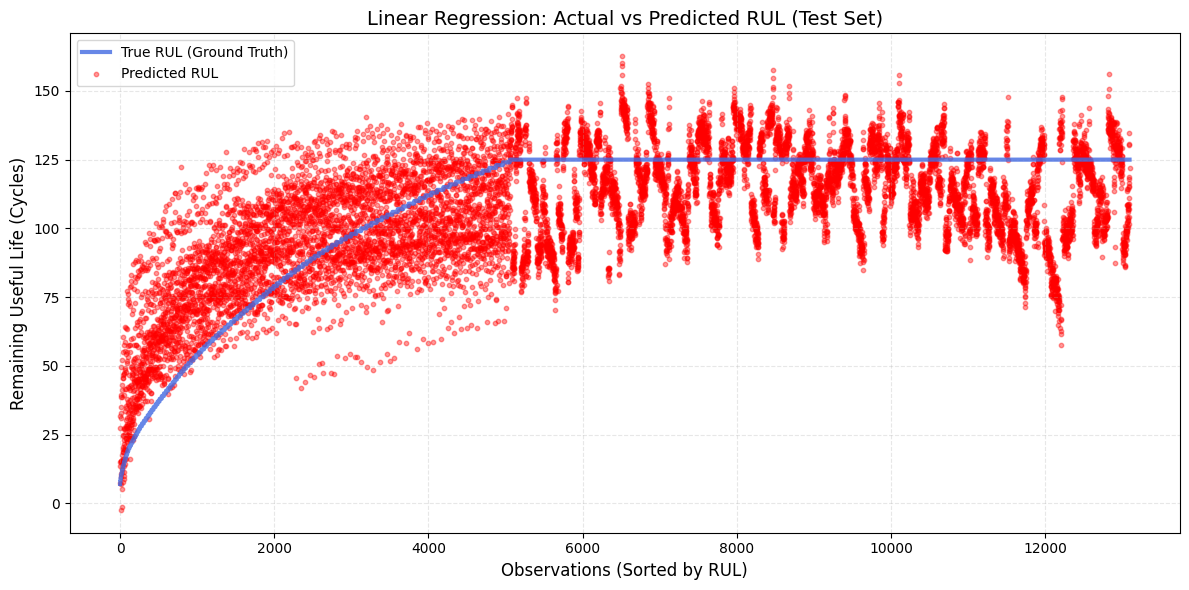

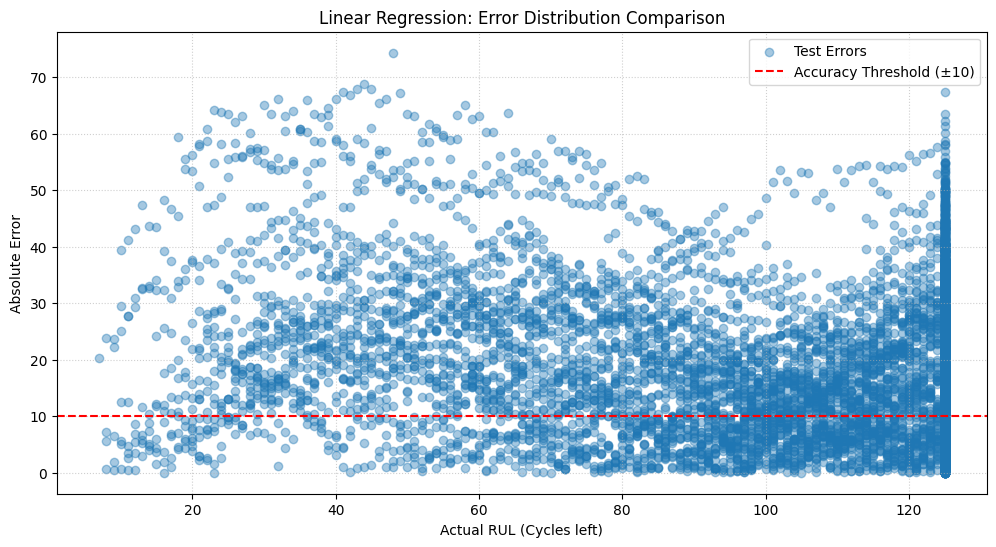


FINAL EVALUATION: Decision Tree

========================= Decision Tree Model Performance =========================
Metric             | Train        | Test        
--------------------------------------------------------------------
RMSE               | 17.4090      | 16.9531     
MAE                | 12.3873      | 11.9572     
R2 Score           | 0.8255       | 0.6221      
NASA Score         | 300397.0643  | 227857.7389 
Accuracy (±10)     | 56.9240      | 61.8509     


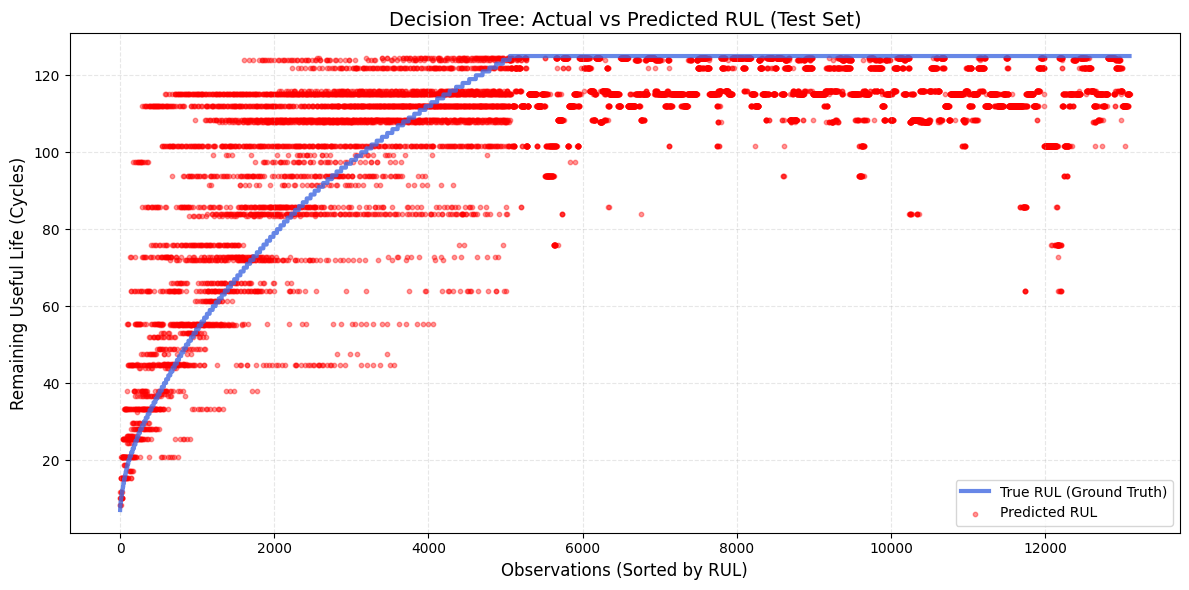

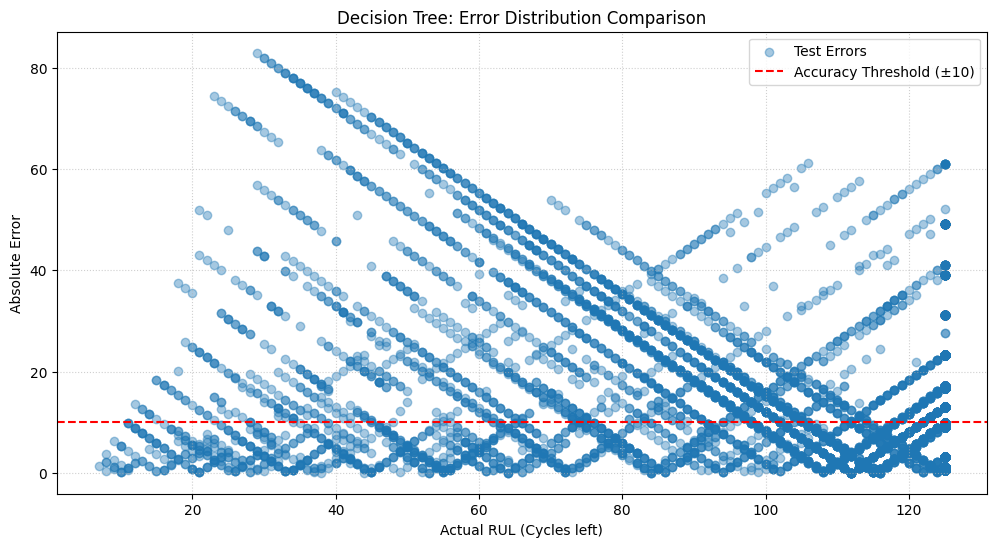


FINAL EVALUATION: Random Forest

========================= Random Forest Model Performance =========================
Metric             | Train        | Test        
--------------------------------------------------------------------
RMSE               | 17.0006      | 16.8423     
MAE                | 12.6100      | 12.5131     
R2 Score           | 0.8336       | 0.6271      
NASA Score         | 228364.9206  | 176018.3521 
Accuracy (±10)     | 49.6244      | 46.9685     


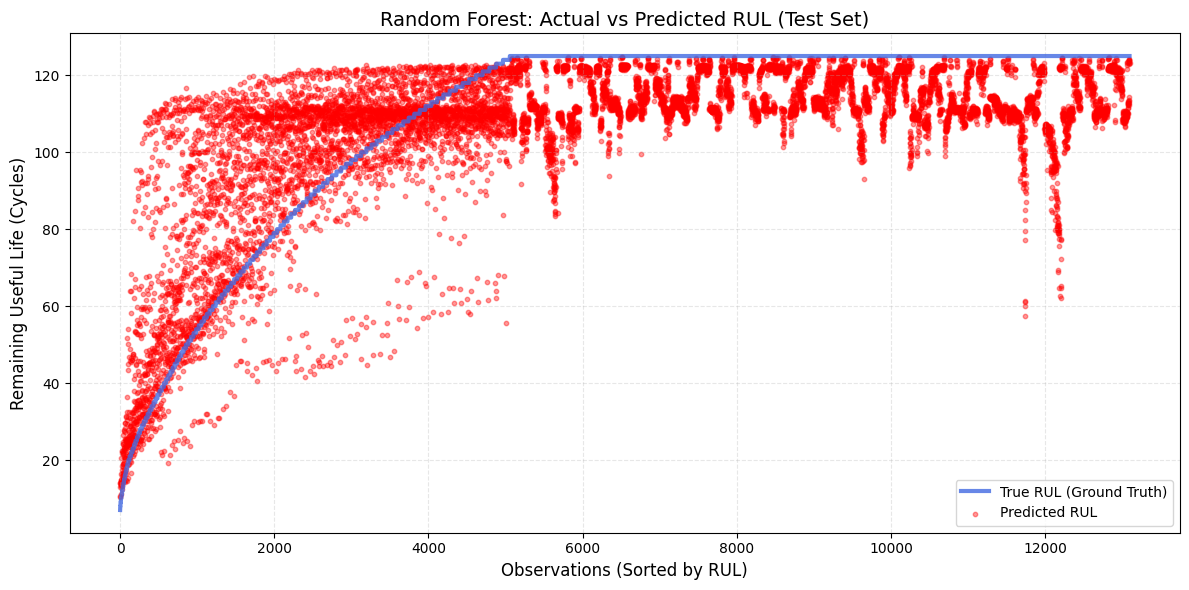

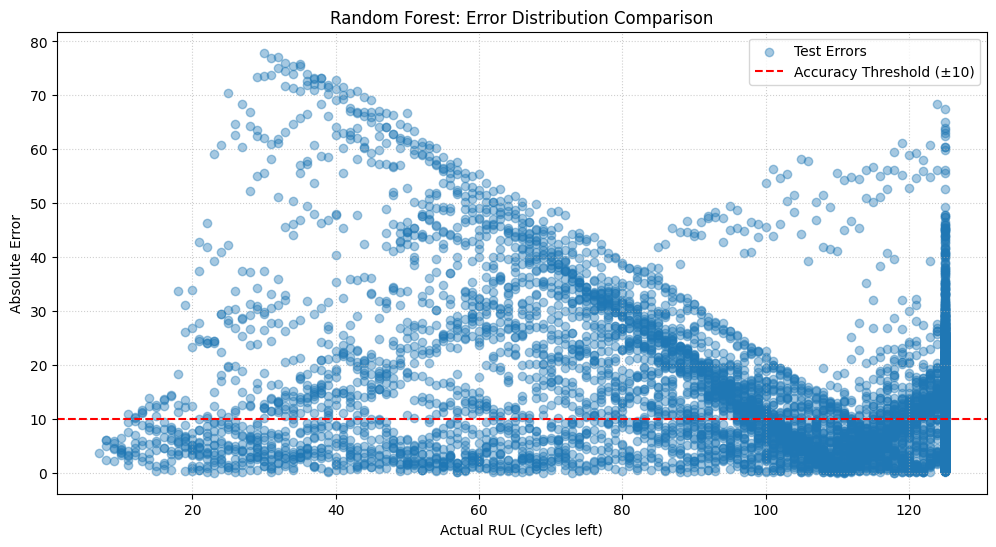


FINAL EVALUATION: XGBoost

========================= XGBoost Model Performance =========================
Metric             | Train        | Test        
--------------------------------------------------------------------
RMSE               | 15.5543      | 16.7399     
MAE                | 11.2046      | 11.7888     
R2 Score           | 0.8607       | 0.6316      
NASA Score         | 157867.9340  | 216651.4517 
Accuracy (±10)     | 57.3651      | 54.9252     


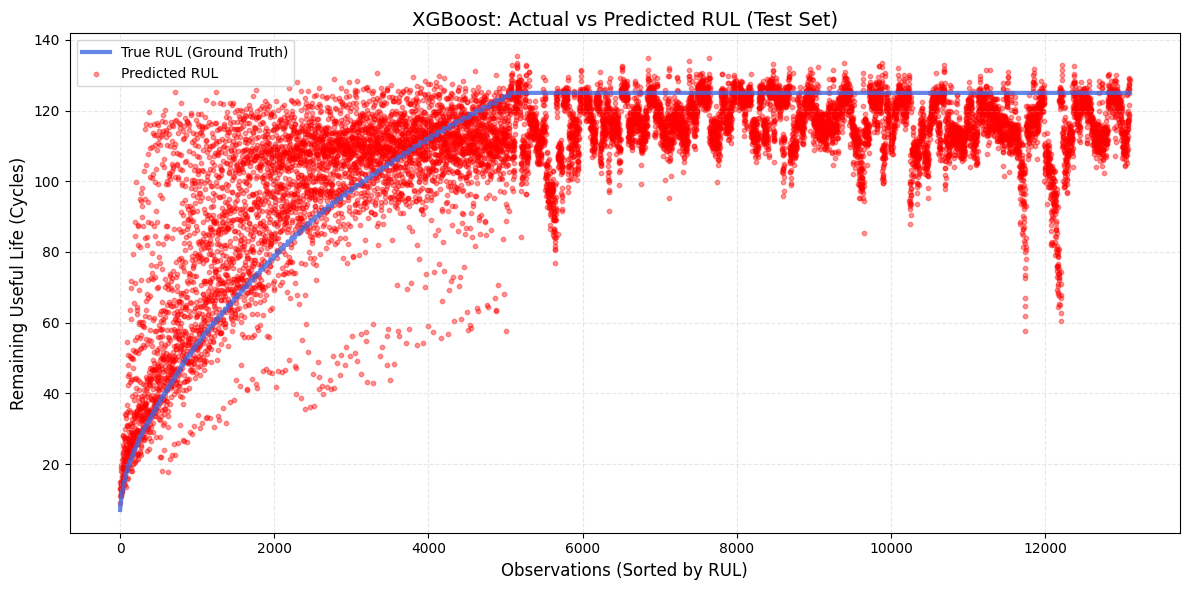

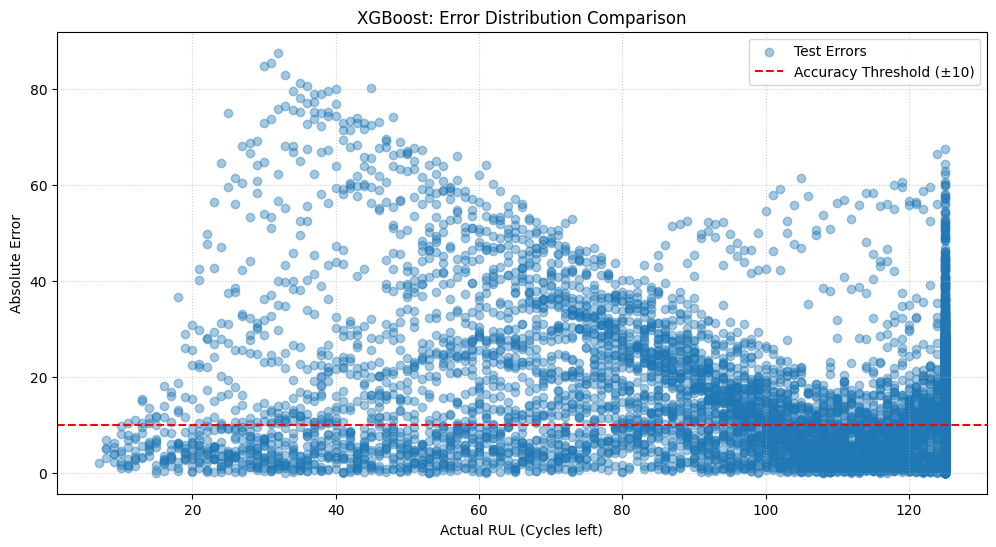


FINAL EVALUATION: SVR

========================= SVR Model Performance =========================
Metric             | Train        | Test        
--------------------------------------------------------------------
RMSE               | 19.0242      | 19.1690     
MAE                | 14.7631      | 14.8802     
R2 Score           | 0.7916       | 0.5169      
NASA Score         | 192906.5006  | 185331.9670 
Accuracy (±10)     | 42.6882      | 42.1121     


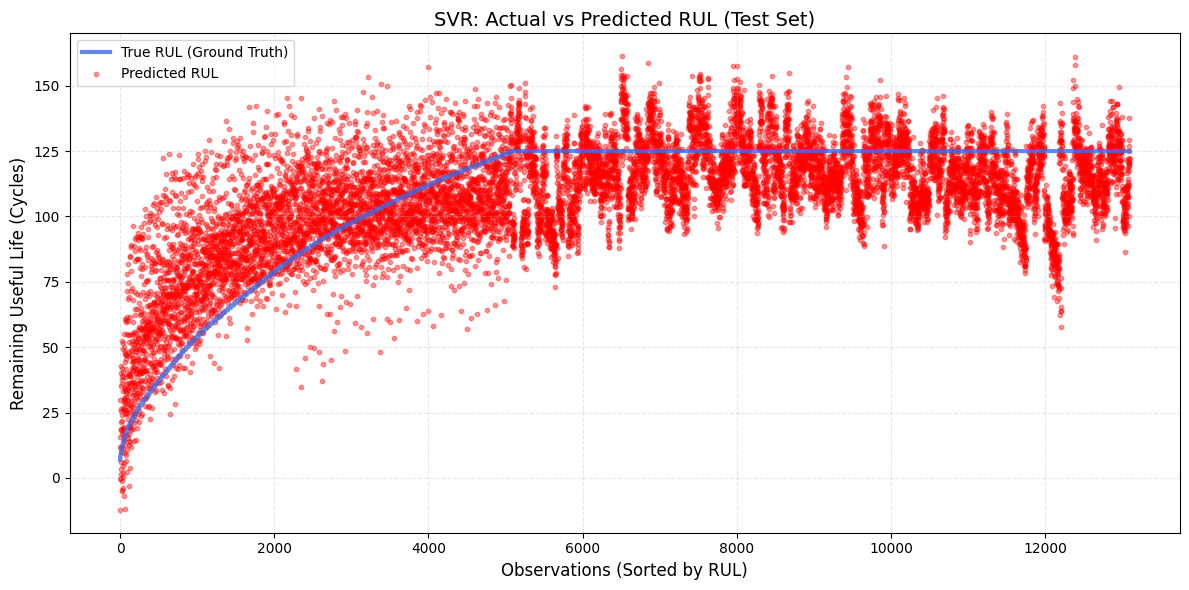

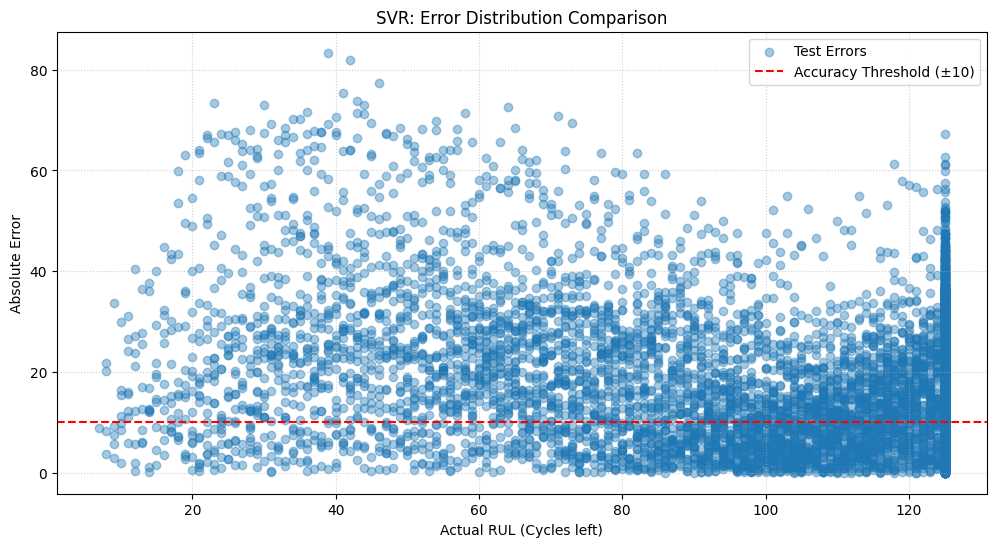


FINAL EVALUATION: Neural Network (ANN)

========================= Neural Network (ANN) Model Performance =========================
Metric             | Train        | Test        
--------------------------------------------------------------------
RMSE               | 16.9439      | 17.0916     
MAE                | 12.4763      | 12.2098     
R2 Score           | 0.8347       | 0.6159      
NASA Score         | 207094.0792  | 273528.0920 
Accuracy (±10)     | 53.1821      | 54.1234     


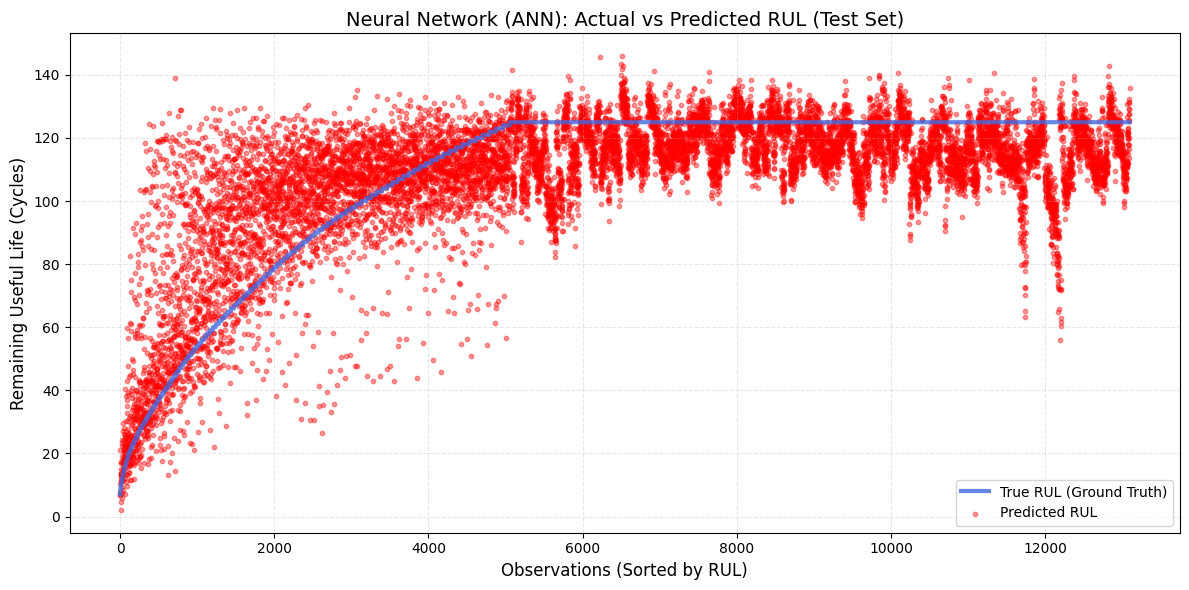

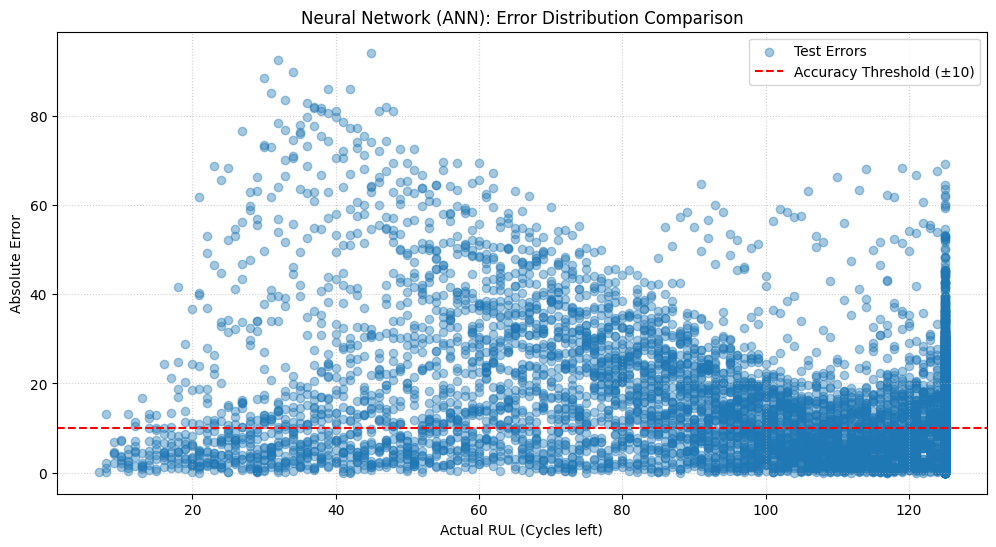


FINAL EVALUATION: LightGBM

========================= LightGBM Model Performance =========================
Metric             | Train        | Test        
--------------------------------------------------------------------
RMSE               | 16.3565      | 16.6893     
MAE                | 11.8095      | 11.7932     
R2 Score           | 0.8459       | 0.6338      
NASA Score         | 194764.4003  | 216657.6741 
Accuracy (±10)     | 54.7865      | 54.0165     


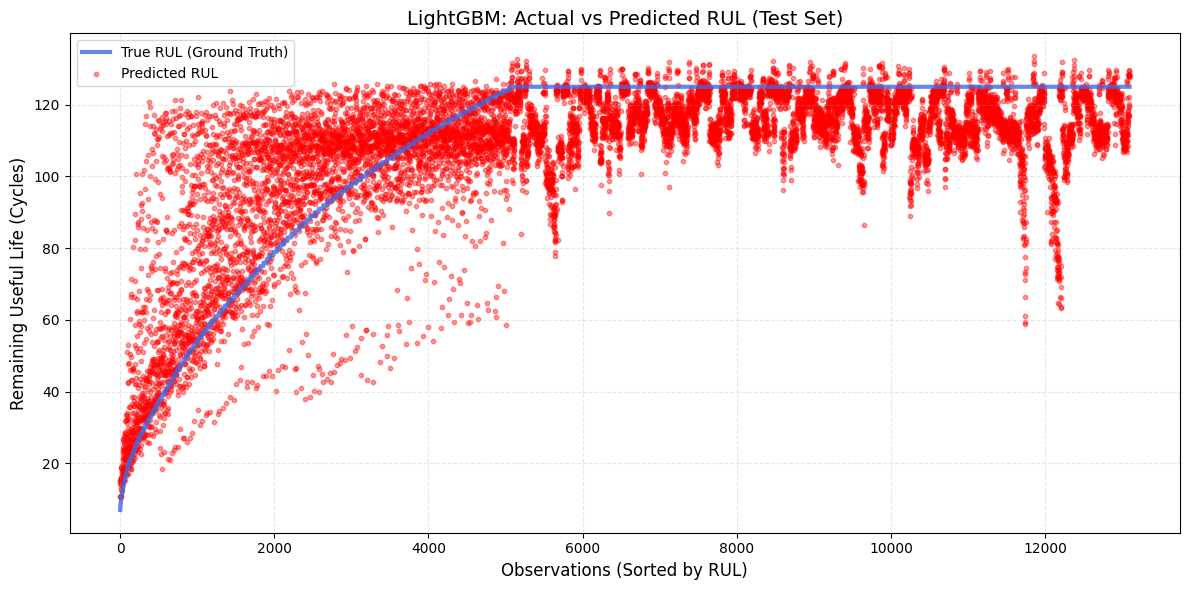

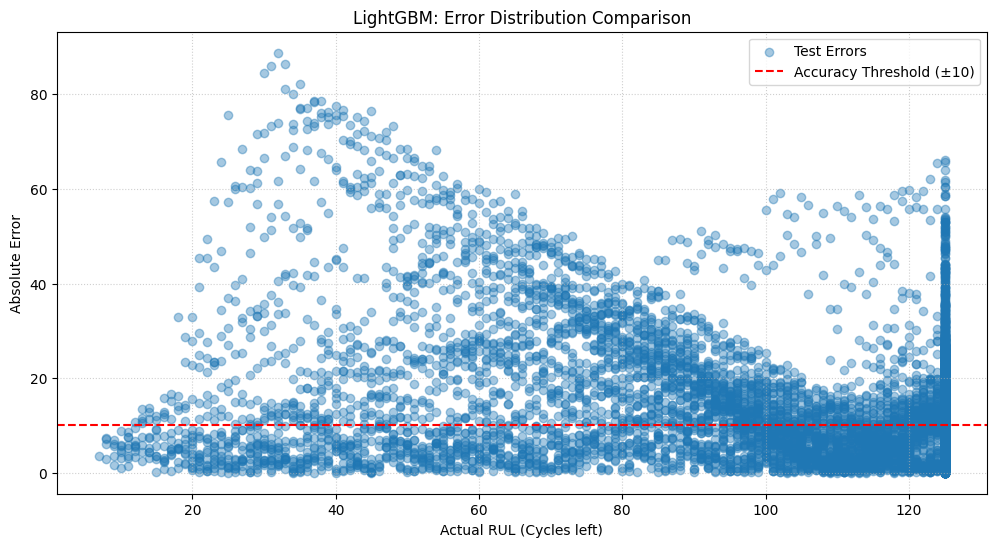

In [12]:
for name, model in models.items():
    print(f"\n" + "="*60)
    print(f"FINAL EVALUATION: {name}")
    print("="*60)
    
    # 1. Generate predictions for all three splits
    # (Using the full datasets as defined in the first step)
    train_preds = model.predict(X_train)
    test_preds  = model.predict(X_test)
    
    # 2. Comprehensive Regression Report
    # Now includes Validation stats to detect overfitting early
    regression_report(
        y_train, train_preds, 
        y_test, test_preds, 
        title=f"{name} Model Performance"
    )
    
    # 3. Visualization: Actual vs Predicted (Test Set)
    # Using the 'Sorted' logic to handle the large number of test rows
    plot_comparison(
        y_test, test_preds, 
        title=f"{name}: Actual vs Predicted RUL (Test Set)"
    )
    
    # 4. Safety Check: Error Alignment
    # Passing both Valid and Test to see if the error patterns are consistent
    check_alignment([
        (y_test, test_preds, "Test")
    ], title=f"{name}: Error Distribution Comparison")

### Model Comparison

,Train_RMSE,Train_MAE,Train_R2,Test_RMSE,Test_MAE,Test_R2
Model,,,,,,
LightGBM,16.356466,11.809507,0.845945,16.689296,11.793184,0.633805
XGBoost,15.554303,11.204624,0.860685,16.739884,11.788772,0.631582
Random Forest,17.000608,12.609973,0.833572,16.842285,12.513102,0.627060
Decision Tree,17.408977,12.387268,0.825481,16.953127,11.957234,0.622135
Neural Network (ANN),16.943903,12.476307,0.834681,17.091589,12.209781,0.615938
SVR,19.024209,14.763050,0.791594,19.168992,14.880201,0.516902
Linear Regression,21.038488,17.194727,0.745126,20.319775,16.239525,0.457157


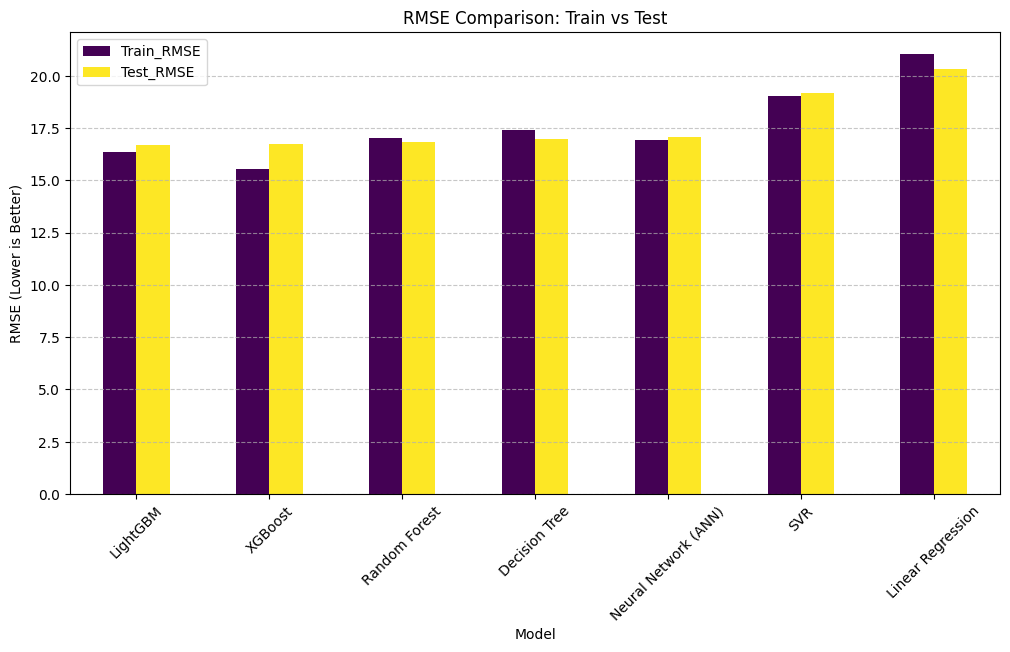

In [13]:
full_report = get_full_performance_report(trained_models, train_df, test_df, feature_cols, target_col)
display(full_report)
plot_split_comparison(full_report)

### Model Performance Comparison (Cross-Validation) ###


,CV_RMSE,CV_MAE,CV_R2
Random Forest,18.116829,13.666787,0.809613
LightGBM,18.143428,13.335499,0.808738
XGBoost,18.151397,13.322655,0.808531
Neural Network (ANN),18.501579,14.038814,0.801902
Decision Tree,18.577326,13.472187,0.800125
SVR,20.736942,16.771935,0.751584
Linear Regression,21.144259,17.301025,0.741712


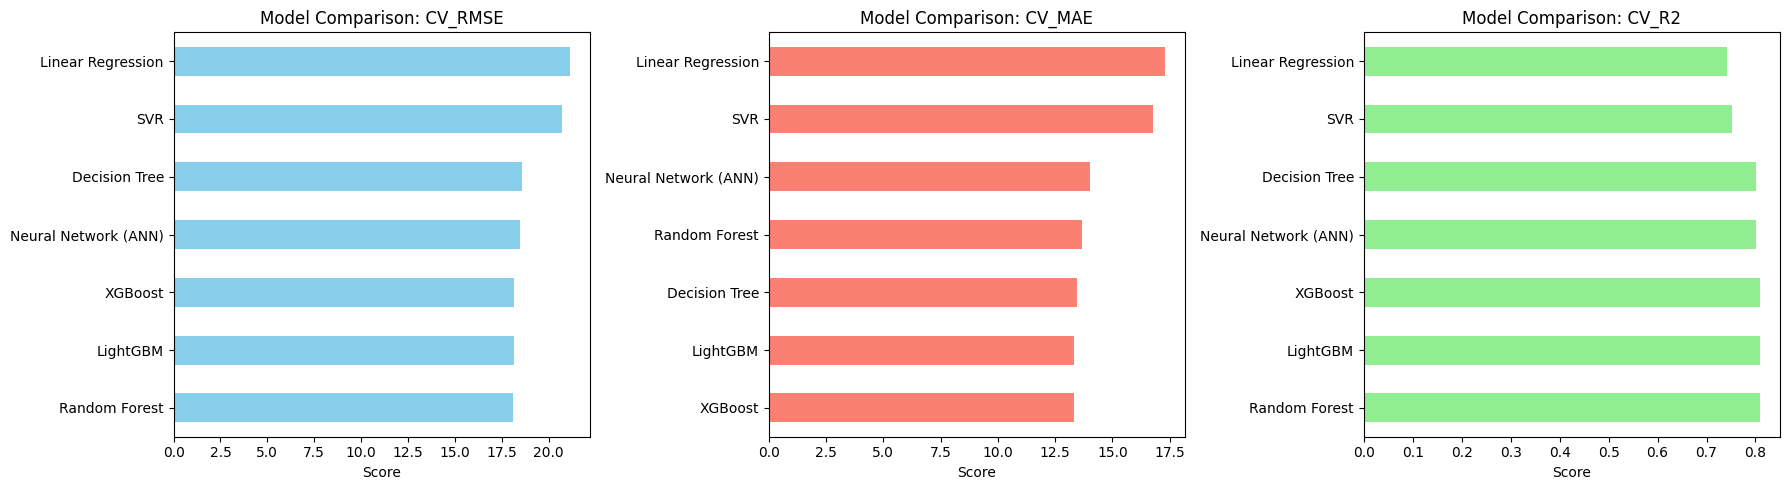

In [14]:
df_comparison = display_model_comparison(results_cv)
plot_model_comparison(df_comparison)

In [15]:
import joblib
import os

# Create the directory if it doesn't exist
os.makedirs('artifacts', exist_ok=True)

# 1. Extract the specific model
rf_model = trained_models["Random Forest"]

# 2. Save it to the artifacts folder
model_path = "../artifacts/random_forest_model.joblib"
joblib.dump(rf_model, model_path)

print(f"Model saved successfully to {model_path}")

Model saved successfully to ../artifacts/random_forest_model.joblib
